<a href="https://colab.research.google.com/github/Tauhid-Topu-007/DEPRESSION-AND-ANXIETY-DETECTION-MODEL-FOR-STUDENTS/blob/main/mmc2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
!pip install catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 9.6 MB/s eta 0:00:00


Dataset shape: (672, 54)
Target distribution:
 target
0    412
1    260
Name: count, dtype: int64
Feature matrix shape: (672, 53)
Top 15 features by F-value:
 7. In the last two weeks, trouble concentrating on things, such as reading the newspaper or watching television._num            206.816020
6. In the last two weeks, feeling bad about yourself-or that you are a failure or have let yourself or your family down._num    200.202873
8. In the last  two weeks, moving or speaking so slowly or the opposite-moving around a lot more than usual._num                191.363426
9. In the last two weeks, thoughts that you would be better off dead, or of hurting yourself in some way._num                   178.126011
5. In the last two weeks, poor appetite or over-eating._num                                                                     140.805905
1. In the last two weeks, I am feeling nervous, anxious, or on edge._num                                                         96.280490
2. In t

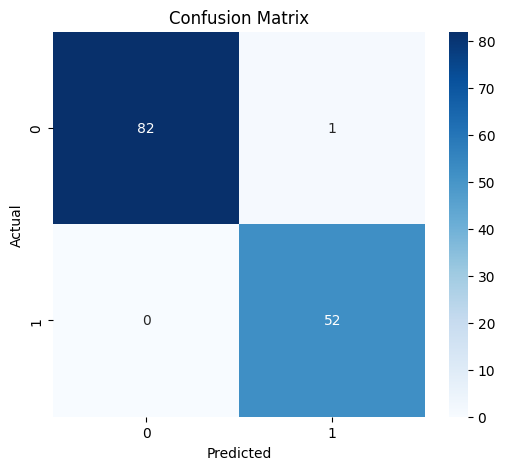


Comparison with other models (Accuracy, F1, AUC):
             acc      f1     auc
Proposed  0.9926  0.9905  1.0000
LR        1.0000  1.0000  1.0000
NB        0.8667  0.8200  0.9356
DT        0.8519  0.8077  0.8436
RF        0.9185  0.8889  0.9891
ET        0.9259  0.9000  0.9880
GB        0.9407  0.9245  0.9926
SVM       0.9481  0.9333  0.9949
XGB       0.9333  0.9109  0.9886
LGBM      0.9481  0.9307  0.9893
CB        0.9481  0.9278  0.9986
SGD       1.0000  1.0000  1.0000
MLP       0.9630  0.9505  0.9991
SHAP values shape (class 1): (50, 10)
Data shape: (50, 10)


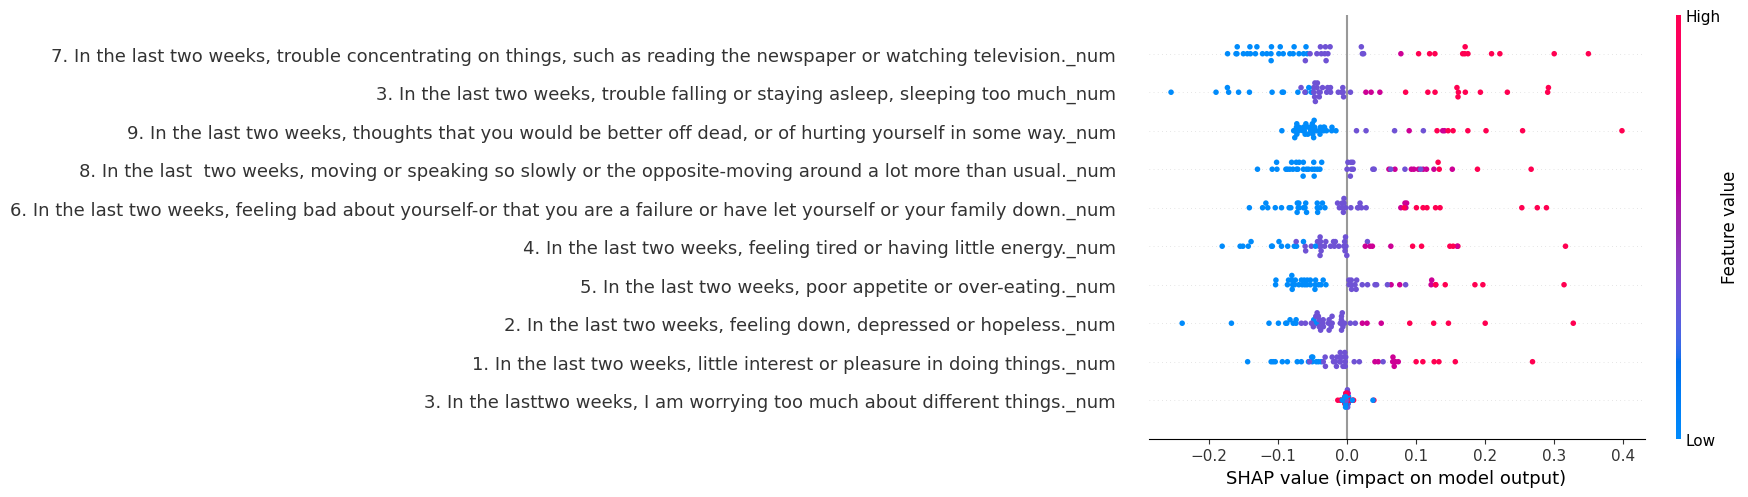

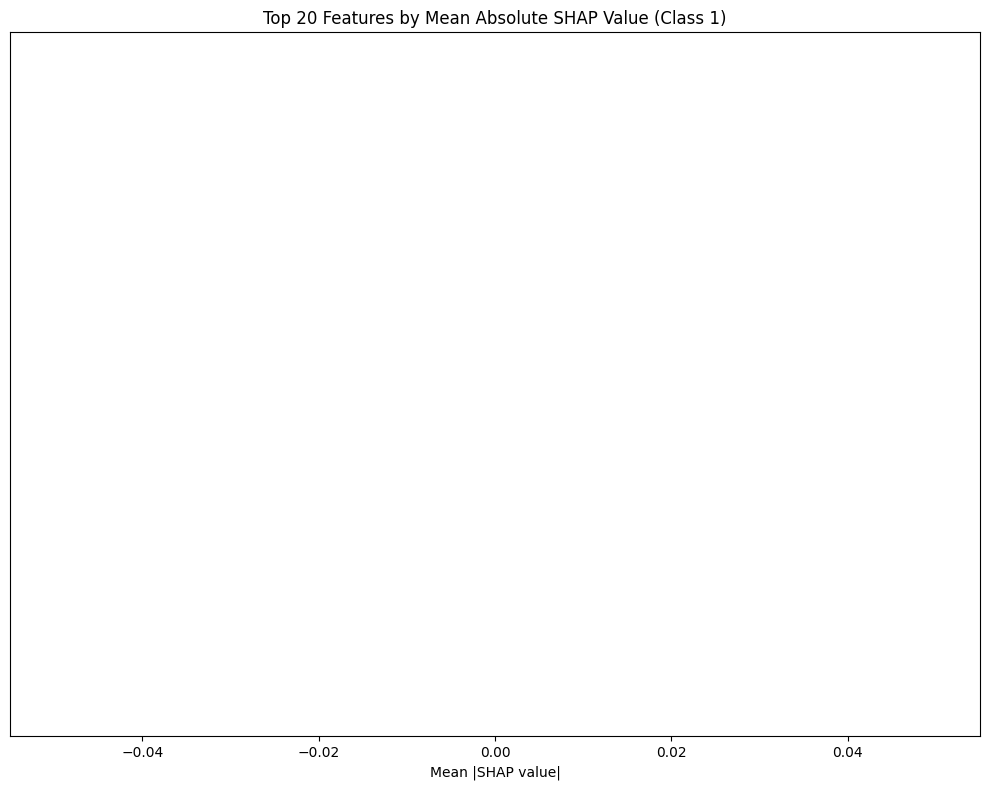

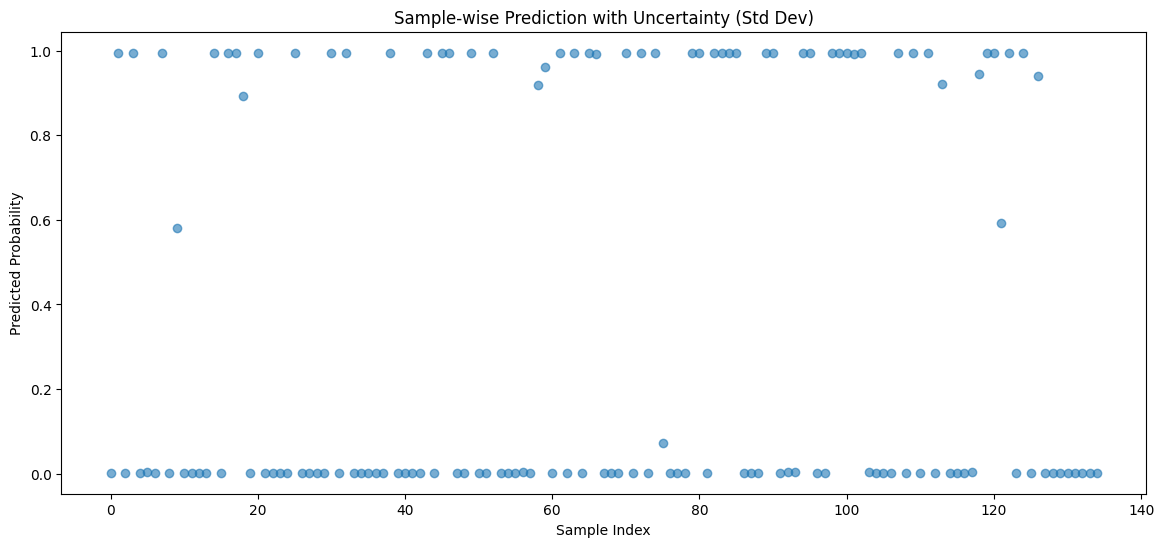

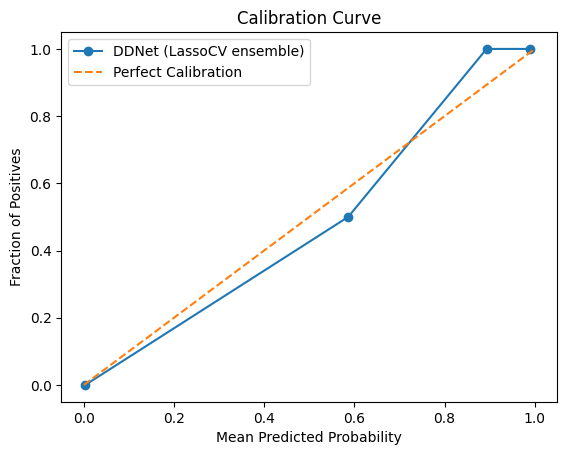

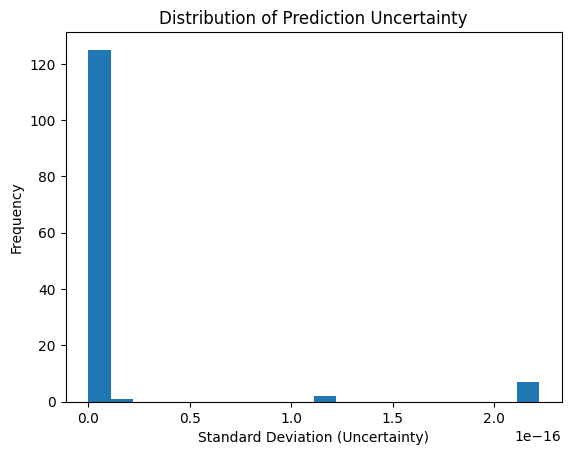

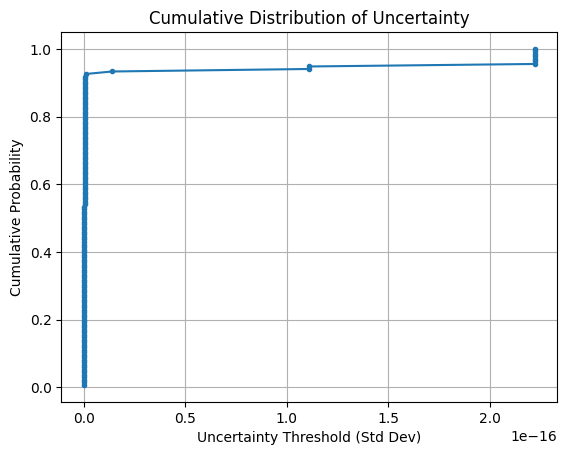


Pipeline completed successfully.


In [64]:
# =============================================================================
# DDNet: Full Implementation for Depression Detection on mmc2.xlsx
# Based on: "DDNet: A Robust and Reliable Hybrid Machine Learning Model..."
# =============================================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, StratifiedKFold, ParameterSampler
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.feature_selection import SelectKBest, f_classif, RFECV
from sklearn.linear_model import LassoCV, SGDClassifier, LogisticRegression
from sklearn.neural_network import MLPClassifier
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             roc_auc_score, log_loss, confusion_matrix, cohen_kappa_score)
from sklearn.base import clone
from sklearn.calibration import calibration_curve

from catboost import CatBoostClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

import shap
from scipy import stats

SEED = 42
np.random.seed(SEED)

# =============================================================================
# 1. Load Dataset and Create Target (PHQ-9 >= 10)
# =============================================================================
df = pd.read_excel('mmc2.xlsx', sheet_name='Sheet1')
print("Dataset shape:", df.shape)

phq_cols = [
    '1. In the last two weeks, little interest or pleasure in doing things.',
    '2. In the last two weeks, feeling down, depressed or hopeless.',
    '3. In the last two weeks, trouble falling or staying asleep, sleeping too much',
    '4. In the last two weeks, feeling tired or having little energy.',
    '5. In the last two weeks, poor appetite or over-eating.',
    '6. In the last two weeks, feeling bad about yourself-or that you are a failure or have let yourself or your family down.',
    '7. In the last two weeks, trouble concentrating on things, such as reading the newspaper or watching television.',
    '8. In the last  two weeks, moving or speaking so slowly or the opposite-moving around a lot more than usual.',
    '9. In the last two weeks, thoughts that you would be better off dead, or of hurting yourself in some way.'
]

def extract_number(text):
    if pd.isna(text):
        return np.nan
    match = re.search(r'\((\d+)\)', str(text))
    if match:
        return int(match.group(1))
    return np.nan

for col in phq_cols:
    df[col + '_num'] = df[col].apply(extract_number)

df['PHQ_total'] = df[[col + '_num' for col in phq_cols]].sum(axis=1)
df['target'] = (df['PHQ_total'] >= 10).astype(int)
print("Target distribution:\n", df['target'].value_counts())

# =============================================================================
# 2. Feature Extraction and Encoding
# =============================================================================
all_cols = df.columns.tolist()
categorical_cols = []
numeric_response_cols = []

for col in all_cols:
    if col in ['target', 'PHQ_total'] or col.endswith('_num'):
        continue
    if 'Express your consent' in col:
        continue
    first_val = df[col].dropna().iloc[0] if not df[col].dropna().empty else ''
    if '(' in str(first_val) and ')' in str(first_val):
        numeric_response_cols.append(col)
    else:
        categorical_cols.append(col)

for col in numeric_response_cols:
    df[col + '_num'] = df[col].apply(extract_number)

feature_cols = []
for col in categorical_cols:
    if col not in ['target', 'PHQ_total']:
        feature_cols.append(col)
for col in numeric_response_cols:
    feature_cols.append(col + '_num')

X = df[feature_cols].copy()
y = df['target'].copy()

for col in categorical_cols:
    if col in X.columns:
        le = LabelEncoder()
        X[col] = le.fit_transform(X[col].astype(str))

X = X.fillna(0)
print("Feature matrix shape:", X.shape)

# =============================================================================
# 3. Scaling
# =============================================================================
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled_df = pd.DataFrame(X_scaled, columns=X.columns)

# =============================================================================
# 4. Feature Selection
# =============================================================================
# ANOVA F-test
selector = SelectKBest(f_classif, k='all')
selector.fit(X_scaled_df, y)
f_values = pd.Series(selector.scores_, index=X.columns)
f_values.sort_values(ascending=False, inplace=True)
print("Top 15 features by F-value:\n", f_values.head(15))

# RFECV
rf = RandomForestClassifier(random_state=SEED, n_jobs=-1)
rfecv = RFECV(estimator=rf, step=1, cv=StratifiedKFold(5), scoring='accuracy', n_jobs=-1)
rfecv.fit(X_scaled_df, y)
optimal_features = X_scaled_df.columns[rfecv.support_]
print(f"Optimal number of features selected: {rfecv.n_features_}")
print("Selected features:", list(optimal_features))

X_selected = X_scaled_df[optimal_features]

# =============================================================================
# 5. Train/Test Split
# =============================================================================
X_train, X_test, y_train, y_test = train_test_split(
    X_selected, y, test_size=0.2, random_state=SEED, stratify=y
)
X_train_np = X_train.values
X_test_np = X_test.values
y_train_np = y_train.values
y_test_np = y_test.values

print(f"Train size: {X_train.shape[0]}, Test size: {X_test.shape[0]}")

# =============================================================================
# 6. Hyperparameter Search Spaces (Random Search)
# =============================================================================
# MLP-1
mlp1_param = {
    'hidden_layer_sizes': [(64, 32), (128, 64), (128, 64, 32)],
    'learning_rate': ['constant', 'adaptive'],
    'alpha': [0.0001, 0.001],
    'max_iter': [1000],
    'random_state': [SEED]
}
mlp1_random = list(ParameterSampler(mlp1_param, n_iter=5, random_state=SEED))

# MLP-2
mlp2_param = {
    'hidden_layer_sizes': [(64, 32), (128, 64), (256, 128)],
    'learning_rate': ['constant', 'adaptive'],
    'alpha': [0.0001, 0.001],
    'max_iter': [1000],
    'random_state': [SEED]
}
mlp2_random = list(ParameterSampler(mlp2_param, n_iter=5, random_state=SEED))

# SGD (only losses that support predict_proba)
sgd_param = {
    'max_iter': [1000, 2000],
    'tol': [1e-4, 1e-3],
    'loss': ['log_loss', 'modified_huber'],
    'penalty': ['l2', 'l1', 'elasticnet'],
    'random_state': [SEED]
}
sgd_random = list(ParameterSampler(sgd_param, n_iter=5, random_state=SEED))

# CatBoost
cat_param = {
    'iterations': [50, 100, 200],
    'depth': [4, 6, 8],
    'learning_rate': [0.01, 0.1, 0.2],
    'verbose': [0],
    'random_state': [SEED]
}
cat_random = list(ParameterSampler(cat_param, n_iter=5, random_state=SEED))

# MLP-3 (second stage)
mlp3_param = {
    'hidden_layer_sizes': [(64, 32), (128, 64), (256, 128)],
    'learning_rate': ['constant', 'adaptive'],
    'alpha': [0.0001, 0.001],
    'max_iter': [1000],
    'random_state': [SEED]
}
mlp3_random = list(ParameterSampler(mlp3_param, n_iter=5, random_state=SEED))

print("Hyperparameter spaces defined.")

# =============================================================================
# 7. Helper: Stacked Meta-feature Generator (5-fold CV)
# =============================================================================
def get_meta_features(models, X_train, y_train, X_test, cv=5):
    n_models = len(models)
    skf = StratifiedKFold(n_splits=cv, shuffle=True, random_state=SEED)
    meta_train = np.zeros((X_train.shape[0], n_models))
    meta_test = np.zeros((X_test.shape[0], n_models))

    for i, (name, model) in enumerate(models):
        oof_preds = np.zeros(X_train.shape[0])
        test_preds = np.zeros(X_test.shape[0])

        for train_idx, val_idx in skf.split(X_train, y_train):
            X_tr, X_val = X_train[train_idx], X_train[val_idx]
            y_tr, y_val = y_train[train_idx], y_train[val_idx]

            model_clone = clone(model)
            model_clone.fit(X_tr, y_tr)
            oof_preds[val_idx] = model_clone.predict_proba(X_val)[:, 1]
            test_preds += model_clone.predict_proba(X_test)[:, 1] / cv

        meta_train[:, i] = oof_preds
        meta_test[:, i] = test_preds

    return meta_train, meta_test

# =============================================================================
# 8. Stage 1: Base Classifiers (MLP-1, MLP-2, SGD)
# =============================================================================
mlp1 = MLPClassifier(**mlp1_random[0])
mlp2 = MLPClassifier(**mlp2_random[0])
sgd = SGDClassifier(**sgd_random[0])

stage1_models = [('MLP1', mlp1), ('MLP2', mlp2), ('SGD', sgd)]
meta_train1, meta_test1 = get_meta_features(
    stage1_models, X_train_np, y_train_np, X_test_np, cv=5
)

print("Stage 1 meta-features shapes:", meta_train1.shape, meta_test1.shape)

# =============================================================================
# 9. Stage 2: Secondary Classifiers (MLP-3, CatBoost)
# =============================================================================
mlp3 = MLPClassifier(**mlp3_random[0])
cat = CatBoostClassifier(**cat_random[0])

stage2_models = [('MLP3', mlp3), ('CatBoost', cat)]
meta_train2, meta_test2 = get_meta_features(
    stage2_models, meta_train1, y_train_np, meta_test1, cv=5
)

print("Stage 2 meta-features shapes:", meta_train2.shape, meta_test2.shape)

# =============================================================================
# 10. Stage 3: Meta-Classifier (LassoCV)
# =============================================================================
lasso = LassoCV(cv=5, alphas=[0.1, 0.01, 0.001], max_iter=1000, random_state=SEED)
lasso.fit(meta_train2, y_train_np)

y_pred_prob = lasso.predict(meta_test2)
y_pred = np.round(y_pred_prob).astype(int)

# =============================================================================
# 11. Evaluation Metrics
# =============================================================================
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
logloss = log_loss(y_test, y_pred_prob)
auc = roc_auc_score(y_test, y_pred_prob)
kappa = cohen_kappa_score(y_test, y_pred)

print("\n" + "="*60)
print("            DDNet MODEL PERFORMANCE")
print("="*60)
print(f"Accuracy:      {acc:.4%}")
print(f"Precision:     {prec:.4%}")
print(f"Recall:        {rec:.4%}")
print(f"F1-Score:      {f1:.4%}")
print(f"Log Loss:      {logloss:.4f}")
print(f"AUC:           {auc:.4f}")
print(f"Cohen's Kappa: {kappa:.4f}")
print("="*60)

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# =============================================================================
# 12. Comparison with Other ML Models
# =============================================================================
other_models = {
    'LR': LogisticRegression(max_iter=1000, random_state=SEED),
    'NB': GaussianNB(),
    'DT': DecisionTreeClassifier(random_state=SEED),
    'RF': RandomForestClassifier(random_state=SEED),
    'ET': ExtraTreesClassifier(random_state=SEED),
    'GB': GradientBoostingClassifier(random_state=SEED),
    'SVM': SVC(probability=True, random_state=SEED),
    'XGB': XGBClassifier(random_state=SEED, use_label_encoder=False, eval_metric='logloss'),
    'LGBM': LGBMClassifier(random_state=SEED, verbose=-1),
    'CB': CatBoostClassifier(iterations=100, depth=6, learning_rate=0.1, verbose=0, random_state=SEED),
    'SGD': SGDClassifier(loss='log_loss', max_iter=1000, random_state=SEED),
    'MLP': MLPClassifier(hidden_layer_sizes=(128, 64, 32), max_iter=1000, random_state=SEED)
}

results_compare = {'Proposed': {'acc': acc, 'f1': f1, 'auc': auc}}
for name, model in other_models.items():
    model.fit(X_train_np, y_train_np)
    y_prob = model.predict_proba(X_test_np)[:, 1]
    y_pred_other = np.round(y_prob).astype(int)
    results_compare[name] = {
        'acc': accuracy_score(y_test, y_pred_other),
        'f1': f1_score(y_test, y_pred_other),
        'auc': roc_auc_score(y_test, y_prob)
    }

comparison_df = pd.DataFrame(results_compare).T
print("\nComparison with other models (Accuracy, F1, AUC):")
print(comparison_df.round(4))

# =============================================================================
# 13. Explainable AI (SHAP) - Using shap.Explainer (No check_additivity)
# =============================================================================
# Retrain MLP-1 on full training set
mlp1_final = clone(mlp1)
mlp1_final.fit(X_train_np, y_train_np)

# Use a subset of training data as background (for speed)
background = X_train_np[np.random.choice(X_train_np.shape[0], 100, replace=False)]

# Choose a subset of test data for explanation
X_test_subset = X_test_np[:50]
feature_names = X_train.columns.tolist()

# Use shap.Explainer with the model's predict_proba
explainer = shap.Explainer(mlp1_final.predict_proba, background)
shap_values = explainer(X_test_subset)   # returns Explanation object with shape (50, 10, 2)

# For binary classification, SHAP values for class 1 are at index 1
shap_values_class1 = shap_values[:, :, 1]   # shape (50, 10)

print("SHAP values shape (class 1):", shap_values_class1.shape)
print("Data shape:", X_test_subset.shape)

# Ensure shapes match
assert shap_values_class1.shape == X_test_subset.shape, \
    f"SHAP shape {shap_values_class1.shape} != data shape {X_test_subset.shape}"

# Summary plot (dot + bar) - pass the class 1 values and the data
shap.summary_plot(shap_values_class1, X_test_subset, feature_names=feature_names)

# Additional bar plot of mean absolute SHAP values (like the paper's bar charts)
mean_abs_shap = np.mean(np.abs(shap_values_class1), axis=0)
sorted_idx = np.argsort(mean_abs_shap)[::-1][:20]  # top 20 features

plt.figure(figsize=(10,8))
plt.barh(np.array(feature_names)[sorted_idx], mean_abs_shap[sorted_idx])
plt.xlabel('Mean |SHAP value|')
plt.title('Top 20 Features by Mean Absolute SHAP Value (Class 1)')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()
# =============================================================================
# 14. Uncertainty Analysis (Ensemble of LassoCV)
# =============================================================================
n_iter = 10
predictions_unc = []
for seed in range(n_iter):
    lasso_unc = LassoCV(cv=5, alphas=[0.1, 0.01, 0.001], max_iter=1000, random_state=seed)
    lasso_unc.fit(meta_train2, y_train_np)
    predictions_unc.append(lasso_unc.predict(meta_test2))

predictions_unc = np.array(predictions_unc)   # (n_iter, n_samples)
mean_pred_unc = np.mean(predictions_unc, axis=0)
std_pred_unc = np.std(predictions_unc, axis=0)

# 1. Sample-wise uncertainty plot
plt.figure(figsize=(14,6))
plt.errorbar(range(len(mean_pred_unc)), mean_pred_unc, yerr=std_pred_unc, fmt='o', alpha=0.6, ecolor='red')
plt.xlabel('Sample Index')
plt.ylabel('Predicted Probability')
plt.title('Sample-wise Prediction with Uncertainty (Std Dev)')
plt.show()

# 2. Calibration curve
prob_true, prob_pred_cal = calibration_curve(y_test, mean_pred_unc, n_bins=10)
plt.plot(prob_pred_cal, prob_true, marker='o', label='DDNet (LassoCV ensemble)')
plt.plot([0, 1], [0, 1], '--', label='Perfect Calibration')
plt.xlabel('Mean Predicted Probability')
plt.ylabel('Fraction of Positives')
plt.legend()
plt.title('Calibration Curve')
plt.show()

# 3. Histogram of uncertainty
plt.hist(std_pred_unc, bins=20)
plt.xlabel('Standard Deviation (Uncertainty)')
plt.ylabel('Frequency')
plt.title('Distribution of Prediction Uncertainty')
plt.show()

# 4. Cumulative probability of uncertainty
sorted_std = np.sort(std_pred_unc)
cum_prob = np.arange(1, len(sorted_std)+1) / len(sorted_std)
plt.plot(sorted_std, cum_prob, marker='.')
plt.xlabel('Uncertainty Threshold (Std Dev)')
plt.ylabel('Cumulative Probability')
plt.title('Cumulative Distribution of Uncertainty')
plt.grid(True)
plt.show()

print("\nPipeline completed successfully.")